# Multimodal Parser Demo

Test parsing, indexing, and RAG agent functionalities.

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

from multimodal_parser import DoclingParser, ChunkType
from multimodal_parser.indexer import DocumentIndexer
from multimodal_parser.agent import RAGAgent

## 1. Parse PDF

In [2]:
parser = DoclingParser()
chunks = parser.parse("../data/files/rag_paper.pdf")

text_chunks = [c for c in chunks if c.chunk_type == ChunkType.TEXT]
table_chunks = [c for c in chunks if c.chunk_type == ChunkType.TABLE]
image_chunks = [c for c in chunks if c.chunk_type == ChunkType.IMAGE]

print(f"Total: {len(chunks)} | Text: {len(text_chunks)} | Tables: {len(table_chunks)} | Images: {len(image_chunks)}")

INFO:multimodal_parser.docling_parser:ModelManager initialized for AI descriptions
INFO:multimodal_parser.docling_parser:Parsing: ../data/files/rag_paper.pdf
INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]
INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash e62bb61b618fb4175c3572edceab1bfb
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered picture descriptions: ['vlm', 'api']
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
INFO:docling.models.stages.ocr.auto_ocr_model:Auto OCR model selected ocrmac.
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered layout engines: ['d

Total: 45 | Text: 34 | Tables: 7 | Images: 4


In [22]:
# Sample text chunk
if text_chunks:
    c = text_chunks[10]
    print("\n[TEXT CHUNK]")
    print(c)


[TEXT CHUNK]
chunk_id='text_10' chunk_type=<ChunkType.TEXT: 'text'> content="3.1 Open-domain Question Answering\nOpen-domain question answering (QA) is an important real-world application and common testbed for knowledge-intensive tasks [20]. We treat questions and answers as input-output text pairs ( x, y ) and train RAG by directly minimizing the negative log-likelihood of answers. We compare RAG to the popular extractive QA paradigm [5, 7, 31, 26], where answers are extracted spans from retrieved documents, relying primarily on non-parametric knowledge. We also compare to 'Closed-Book QA' approaches [52], which, like RAG, generate answers, but which do not exploit retrieval, instead relying purely on parametric knowledge. We consider four popular open-domain QA datasets: Natural Questions (NQ) [29], TriviaQA (TQA) [24]. WebQuestions (WQ) [3] and CuratedTrec (CT) [2]. As CT and WQ are small, we follow DPR [26] by initializing CT and WQ models with our NQ RAG model. We use the same t

In [30]:
# Sample table chunk
if table_chunks:
    c = table_chunks[0]
    print("\n[TABLE CHUNK]")
    print(c)


[TABLE CHUNK]
chunk_id='table_35' chunk_type=<ChunkType.TABLE: 'table'> content='This table presents the performance of various Open-Domain Question Answering (QA) models, including T5, REALM, DPR, and RAG-Token, categorized by their approach (Closed Book or Open Book). It provides numerical test scores across multiple' sequence_number=35 source_document='rag_paper.pdf' source_page=6 parent_heading='4.1 Open-domain Question Answering' extraction_timestamp=datetime.datetime(2026, 2, 3, 18, 51, 7, 549485) dataframe=                         Model    NQ              TQA    WQ    CT
0  Closed Book     T5-11B [52]  34.5  - /50.1 - /60.5  37.4   - -
1               T5-11B+SSM[52]  36.6                   44.7      
2         Open      REALM [20]  40.4            - / -  40.7  46.8
3         Book        DPR [26]  41.5         57.9 / -  41.1  50.6
4                    RAG-Token  44.1        55.2/66.1  45.5  50.0
5                     RAG-Seq.  44.5       56.8/ 68.0  45.2  52.2 columns=None num_r


[IMAGE CHUNK]


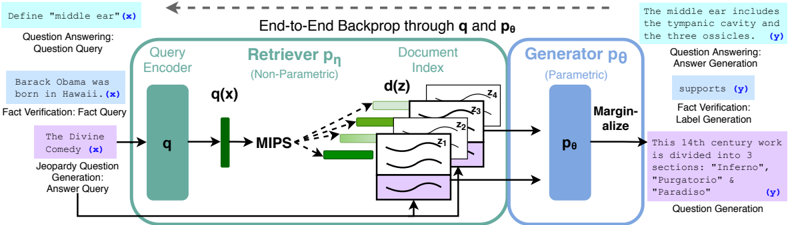

chunk_id='image_34' chunk_type=<ChunkType.IMAGE: 'image'> content='This is a **system architecture diagram** illustrating a retrieval-augmented generation (RAG) model.\n\nThe main subject is the **end-to-end backpropagation through a retriever and a generator**\n\nCaption: Figure 1: Overview of our approach. We combine a pre-trained retriever ( Query Encoder + Document Index ) with a pre-trained seq2seq model ( Generator ) and fine-tune end-to-end. For query x , we use Maximum Inner Product Search (MIPS) to find the top-K documents z i . For final prediction y , we treat z as a latent variable and marginalize over seq2seq predictions given different documents.' sequence_number=34 source_document='rag_paper.pdf' source_page=2 parent_heading='1 Introduction' extraction_timestamp=datetime.datetime(2026, 2, 3, 18, 51, 1, 688668) image_path='/Users/maharora/Documents/Work/Other/multimodal-parser/multimodal_parser/data/images/rag_paper_bc273647-e18b-4140-a535-06365eea4a54.png' image_format='

In [32]:
# Sample image chunk
from IPython.display import Image as IPImage, display

if image_chunks:
    c = image_chunks[0]
    print("\n[IMAGE CHUNK]")
    if c.image_path:
        display(IPImage(filename=c.image_path, width=400))
    print(c)

## 2. Index to Qdrant

In [6]:
indexer = DocumentIndexer(qdrant_path="../qdrant_data", force_reset=True)
count = indexer.index_folder("../data/files")
print(f"Indexed {count} chunks")
indexer.close()

INFO:multimodal_parser.indexer:Cleared existing Qdrant data: ../qdrant_data
INFO:multimodal_parser.docling_parser:ModelManager initialized for AI descriptions
INFO:multimodal_parser.indexer:Created collection: document_chunks (vector_size=3072)
INFO:multimodal_parser.indexer:Found 2 files to process
INFO:multimodal_parser.docling_parser:Parsing: ../data/files/llm_as_a_judge.pdf
INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]
INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash e62bb61b618fb4175c3572edceab1bfb
INFO:docling.models.stages.ocr.auto_ocr_model:Auto OCR model selected ocrmac.
INFO:docling.utils.accelerator_utils:Accelerator device: 'mps'
INFO:docling.utils.accelerator_utils:Accelerator device: 'mps'
INFO:docling.pipeline.base_pipeline:Processing document llm_as_a_judge.pdf
INFO:docling.document_converter:Finished converting document llm_as

Indexed 130 chunks


## 3. Query with RAG Agent

In [33]:
agent = RAGAgent(qdrant_path="../qdrant_data", top_k=5)

In [34]:
# Text-based query
result = agent.query("What is RAG and how does it combine retrieval with generation to improve factual accuracy?")
print(result["answer"])
print(f"\nSources: {result['sources']}")

Retrieval-Augmented Generation (RAG) is a model that combines a pre-trained retriever with a pre-trained sequence-to-sequence (seq2seq) generator, fine-tuning them end-to-end. As illustrated in Figure 1, it works by using an input query to retrieve relevant text documents, which then serve as additional context for the generator to produce a target sequence.

RAG improves factual accuracy by:
*   **Leveraging retrieved documents as context:** The retriever (e.g., Dense Passage Retriever or DPR) provides latent documents based on the input. The seq2seq model (e.g., BART) then uses these retrieved documents, along with the original input, to generate the output. This allows the model to access and incorporate external knowledge.
*   **Marginalizing over latent documents:** RAG models can marginalize over these retrieved documents in different ways (RAG-Sequence uses the same document for all tokens, while RAG-Token can use different documents for different tokens), enabling a more flexib

The RAG model architecture, as shown in the diagram, combines a pre-trained retriever with a pre-trained sequence-to-sequence (seq2seq) generator, fine-tuned end-to-end.

Here's how the retriever and generator components work together:
1.  **Retriever**: Given an input query `x`, the retriever (composed of a Query Encoder and Document Index) uses Maximum Inner Product Search (MIPS) to find the top-K most relevant documents, denoted as `z_i`. These retrieved documents serve as additional context.
2.  **Generator**: The generator, a pre-trained seq2seq model, then takes the original input `x` and the retrieved documents `z` as context. It generates the target sequence `y` token by token. The retrieved document `z` is treated as a latent variable, and the model marginalizes over the seq2seq predictions made with different retrieved documents to produce the final output.

In essence, the retriever provides relevant information from a non-parametric memory (document index) to the generator,

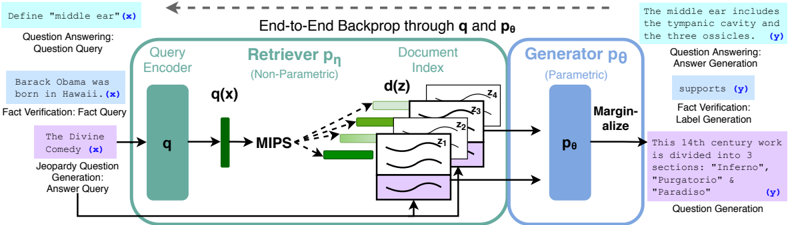

In [35]:
# Image query
result = agent.query("Show me the architecture diagram of RAG and explain how the retriever and generator components work together")
print(result["answer"])

for img in result["images"]:
    print(f"\nImage: {img['description'][:100]}...")
    if img.get("path"):
        display(IPImage(filename=img["path"], width=500))

In [36]:
# Table query
result = agent.query("From the LLM-as-a-Judge paper results table, which model has the highest agreement rate with human judges? List the top 3 models with their exact scores.")
print(result["answer"])

for tbl in result["tables"]:
    print(f"\nSQL: {tbl['sql']}")
    print(f"Result: {tbl['result']}")

Based on the meta-evaluation results for different LLMs in Table 2, the top 3 models with the highest agreement rate with human judges are:

1.  o3-mini: 61.66%
2.  GPT-4-turbo: 61.54%
3.  gemini-2.0-thinking: 60.75%


In [37]:
agent.close()